# 08\_training\_router\_with\_images.ipynb

Multimodal router training notebook that:

- Loads **train / val / test** router datasets from Parquet, with **image bytes (`image_png`) and text**.
- Builds a **CLIP-based vision encoder** + **Transformer-based text encoder**.
- Trains a **multimodal router classifier** to pick the best VLM per sample.
- Logs metrics and plots to **Weights & Biases (W&B)**, including:
  - Train / validation loss & accuracy per epoch
  - Final test accuracy and confusion matrix
  - Pareto-style **cost vs utility** scatter plot

> **Note:** This notebook assumes you already ran `07_build_train_datasets.ipynb` and produced the `router_*_trainer.parquet` files with `image_png` and routing labels.


In [1]:
import os
import io
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import List, Dict, Optional

import numpy as np
import pandas as pd
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModel,
    CLIPImageProcessor,
    CLIPVisionModel,
)

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import plotly.express as px

try:
    import wandb
    WANDB_AVAILABLE = True
except ImportError:
    print("wandb not installed; W&B logging will be disabled.")
    WANDB_AVAILABLE = False

print("Python, Torch, Transformers, etc. imported.")

/home/hice1/vchopra37/scratch/projects/vlm_router/vlm_router_env/lib/python3.12/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


Python, Torch, Transformers, etc. imported.


In [2]:
# ---- Config dataclass ----
@dataclass
class RouterConfig:
    # Paths
    project_root: Path = Path.cwd().parent  # adjust if needed
    data_root: Path = Path.cwd().parent.parent.parent / "dataset" / "final_dataset" 
    router_subdir: str = "router_lexico"  # where 07_build_train_datasets wrote trainer files
    output_dir: Path = Path.cwd() / "router_training_outputs"
    checkpoint_dir: Path = Path.cwd() / "router_checkpoints"

    def __post_init__(self):
        self.output_dir.mkdir(parents=True, exist_ok=True)
        self.checkpoint_dir.mkdir(parents=True, exist_ok=True)
        
    # Trainer parquet filenames (one per split)
    train_file: str = "router_train_trainer.parquet"
    val_file: str   = "router_val_trainer.parquet"
    test_file: str  = "router_test_trainer.parquet"

    # Optional: image_root only used as fallback if image_png bytes missing
    image_root: Path = Path.cwd().parent.parent.parent / "dataset" / "which_vlm_data" / "images"

    # Model + tokenizer
    vision_encoder_name: str = "openai/clip-vit-base-patch32"
    text_encoder_name: str   = "distilbert-base-uncased"
    text_tokenizer_name: str = "distilbert-base-uncased"

    use_image: bool = True
    freeze_vision: bool = True
    freeze_text_encoder: bool = False

    # Training hyperparams
    num_epochs: int = 5
    train_batch_size: int = 16
    eval_batch_size: int = 32
    learning_rate: float = 3e-5
    weight_decay: float = 0.01
    max_grad_norm: float = 1.0
    max_text_length: int = 256

    # Loss configuration
    use_soft_labels: bool = True
    ce_weight: float = 1.0
    kl_weight: float = 0.5
    label_smoothing: float = 0.0

    # Misc
    num_workers: int = 4
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    seed: int = 42

    # Logging
    use_wandb: bool = True
    wandb_project: str = "vlm-router"
    wandb_entity: Optional[str] = None  # set if you have a W&B team
    wandb_run_name: str = "router_with_images"

        
config = RouterConfig()

# ---- Seeding ----
def set_seed(seed: int):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(config.seed)

print(config)
print("Using device:", config.device)

RouterConfig(project_root=PosixPath('/storage/ice1/1/0/vchopra37/projects/vlm_router/code_base/which_vlm'), data_root=PosixPath('/storage/ice1/1/0/vchopra37/projects/vlm_router/dataset/final_dataset'), router_subdir='router_lexico', output_dir=PosixPath('/storage/ice1/1/0/vchopra37/projects/vlm_router/code_base/which_vlm/artemis/router_training_outputs'), checkpoint_dir=PosixPath('/storage/ice1/1/0/vchopra37/projects/vlm_router/code_base/which_vlm/artemis/router_checkpoints'), train_file='router_train_trainer.parquet', val_file='router_val_trainer.parquet', test_file='router_test_trainer.parquet', image_root=PosixPath('/storage/ice1/1/0/vchopra37/projects/vlm_router/dataset/which_vlm_data/images'), vision_encoder_name='openai/clip-vit-base-patch32', text_encoder_name='distilbert-base-uncased', text_tokenizer_name='distilbert-base-uncased', use_image=True, freeze_vision=True, freeze_text_encoder=False, num_epochs=5, train_batch_size=16, eval_batch_size=32, learning_rate=3e-05, weight_de

In [3]:
# ---- Load trainer parquet datasets ----
router_dir = config.data_root / config.router_subdir
print("Router data dir:", router_dir)

train_path = router_dir / config.train_file
val_path   = router_dir / config.val_file
test_path  = router_dir / config.test_file

print("Train path:", train_path)
print("Val path  :", val_path)
print("Test path :", test_path)

train_df = pd.read_parquet(train_path)
val_df   = pd.read_parquet(val_path)
test_df  = pd.read_parquet(test_path)

print("\nShapes:")
print("train_df:", train_df.shape)
print("val_df  :", val_df.shape)
print("test_df :", test_df.shape)

print("\nTrain columns (first 40):")
print(train_df.columns[:40])

display(train_df.head())

Router data dir: /storage/ice1/1/0/vchopra37/projects/vlm_router/dataset/final_dataset/router_lexico
Train path: /storage/ice1/1/0/vchopra37/projects/vlm_router/dataset/final_dataset/router_lexico/router_train_trainer.parquet
Val path  : /storage/ice1/1/0/vchopra37/projects/vlm_router/dataset/final_dataset/router_lexico/router_val_trainer.parquet
Test path : /storage/ice1/1/0/vchopra37/projects/vlm_router/dataset/final_dataset/router_lexico/router_test_trainer.parquet

Shapes:
train_df: (63963, 33)
val_df  : (13706, 33)
test_df : (13707, 33)

Train columns (first 40):
Index(['sample_id', 'image_path', 'image_bytes_hash', 'prompt_raw',
       'img_width', 'img_height', 'img_aspect_ratio',
       'txt_prompt_length_chars', 'txt_prompt_length_words', 'router_task',
       'source_dataset', 'source_config', 'txt_question_type',
       'txt_has_mc_options', 'ground_truth', 'ground_truth_type',
       'router_best_model_id', 'router_best_model_name', 'router_chosen_perf',
       'router_chos

,sample_id,image_path,image_bytes_hash,prompt_raw,img_width,img_height,img_aspect_ratio,txt_prompt_length_chars,txt_prompt_length_words,router_task,...,label_name,utility_scheme,hier_w_sample,hier_w_task,hier_w_global,router_soft_p_deepseek_ocr,router_soft_p_qwen2_5_vl_3b,router_soft_p_qwen2_5_vl_7b,router_soft_p_qwen3_vl_8b_thinking,router_soft_p_gemma_3_27b
0,ai2d_00000_45f9e7163ea99b4c,None,45f9e7163ea99b4c,Question: What do respiration and combustion g...,299.0,227.0,1.317,134.0,22.0,diagram_reasoning,...,qwen2_5_vl_7b,lexico_d0.02,0.6,0.35,0.05,0.0,0.090526,0.909474,0.0,0.0
1,ai2d_00001_0135592f21ea024d,None,0135592f21ea024d,"Question: From the given food web, name any tw...",715.0,517.0,1.383,175.0,28.0,diagram_reasoning,...,qwen2_5_vl_7b,lexico_d0.02,0.6,0.35,0.05,0.0,0.090537,0.909463,0.0,0.0
2,ai2d_00002_df53e5451d7476fe,None,df53e5451d7476fe,Question: Anatomy One of a series of long curv...,320.0,285.0,1.123,166.0,31.0,diagram_reasoning,...,qwen2_5_vl_7b,lexico_d0.02,0.6,0.35,0.05,0.0,0.090527,0.909473,0.0,0.0
3,ai2d_00003_49e0ce3c07c66e5c,None,49e0ce3c07c66e5c,Question: What process does this diagram portr...,416.0,284.0,1.465,141.0,22.0,diagram_reasoning,...,qwen2_5_vl_7b,lexico_d0.02,0.6,0.35,0.05,0.0,0.090528,0.909472,0.0,0.0
4,ai2d_00005_a70e661f5c7ae68d,None,a70e661f5c7ae68d,Question: Which type of rock consists of molte...,960.0,720.0,1.333,166.0,26.0,diagram_reasoning,...,qwen2_5_vl_7b,lexico_d0.02,0.6,0.35,0.05,0.0,0.090548,0.909452,0.0,0.0


In [4]:
# ---- Extract utility scheme and hierarchical weights from trainer data ----
if "utility_scheme" in train_df.columns:
    DATA_UTILITY_SCHEME = str(train_df["utility_scheme"].iloc[0])
else:
    DATA_UTILITY_SCHEME = "unknown"

HIER_W_SAMPLE = float(train_df.get("hier_w_sample", pd.Series([np.nan])).iloc[0])
HIER_W_TASK   = float(train_df.get("hier_w_task",   pd.Series([np.nan])).iloc[0])
HIER_W_GLOBAL = float(train_df.get("hier_w_global", pd.Series([np.nan])).iloc[0])

print("Utility metadata from trainer dataset:")
print("  utility_scheme:", DATA_UTILITY_SCHEME)
print("  hier_w_sample :", HIER_W_SAMPLE)
print("  hier_w_task   :", HIER_W_TASK)
print("  hier_w_global :", HIER_W_GLOBAL)

Utility metadata from trainer dataset:
  utility_scheme: lexico_d0.02
  hier_w_sample : 0.6
  hier_w_task   : 0.35
  hier_w_global : 0.05


Random sample index: 41905
sample_id: scienceqa_00498_4e1fb0dae7c6461b
router_task: science_reasoning
router_best_model_id: 2
router_best_model_name: qwen2_5_vl_7b

Prompt:
Lecture: A continent is one of the major land masses on the earth. Most people say there are seven continents.
Question: Which continent is highlighted?
Choices:
A. Australia
B. Asia
C. Africa
D. Antarctica
Answer with the letter.


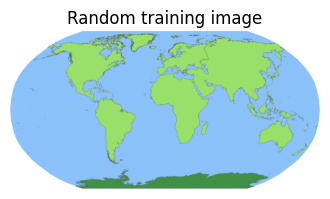

In [5]:
# ---- Visual sanity check: show a random training sample (image + prompt) ----
import random

rand_idx = random.randint(0, len(train_df) - 1)
row = train_df.iloc[rand_idx]

print("Random sample index:", rand_idx)
print("sample_id:", row.get("sample_id"))
print("router_task:", row.get("router_task"))
print("router_best_model_id:", row.get("router_best_model_id"))
print("router_best_model_name:", row.get("router_best_model_name"))
print("\nPrompt:")
print(row.get("prompt_raw"))

if "image_png" in row and isinstance(row["image_png"], (bytes, bytearray, memoryview)):
    img = Image.open(io.BytesIO(row["image_png"])).convert("RGB")
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Random training image")
    plt.show()
else:
    print("No image_png bytes found for this sample.")

In [6]:
# ---- RouterDataset: loads from image_png bytes when available ----
class RouterDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        image_root: Path,
        image_processor: CLIPImageProcessor,
        tokenizer,
        config: RouterConfig,
        model_names: List[str],
    ):
        self.df = df.reset_index(drop=True)
        self.image_root = image_root
        self.image_processor = image_processor
        self.tokenizer = tokenizer
        self.config = config
        self.model_names = model_names

        soft_prefix = "router_soft_p_"
        self.soft_label_cols = [
            f"{soft_prefix}{m}" for m in model_names
            if f"{soft_prefix}{m}" in df.columns
        ]
        self.has_soft_labels = len(self.soft_label_cols) == len(model_names)

    def __len__(self):
        return len(self.df)

    def _load_image(self, row) -> torch.Tensor:
        """Load image, preferring image_png bytes, with fallback to disk."""
        # 1) Try image_png bytes
        if "image_png" in row.index:
            img_bytes = row["image_png"]
            if isinstance(img_bytes, (bytes, bytearray, memoryview)):
                try:
                    pil_img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
                    inputs = self.image_processor(images=pil_img, return_tensors="pt")
                    pixel_values = inputs["pixel_values"].squeeze(0)
                    return pixel_values
                except Exception as e:
                    print(f"[WARN] Failed to decode image_png for sample_id={row.get('sample_id', 'NA')}: {e}")

        # 2) Fallback: disk-based loading via image_path
        img_path = row.get("image_path", None)
        if img_path is None or not isinstance(img_path, str):
            return torch.zeros(3, 224, 224)

        full_path = self.image_root / img_path
        if not full_path.exists():
            return torch.zeros(3, 224, 224)

        inputs = self.image_processor(images=str(full_path), return_tensors="pt")
        pixel_values = inputs["pixel_values"].squeeze(0)
        return pixel_values

    def _build_router_text(self, row) -> str:
        prompt = row.get("prompt_raw", "")

        w = row.get("img_width", None)
        h = row.get("img_height", None)
        ar = row.get("img_aspect_ratio", None)
        len_chars = row.get("txt_prompt_length_chars", None)
        len_words = row.get("txt_prompt_length_words", None)

        meta_parts = []
        if len_words is not None and not np.isnan(len_words):
            meta_parts.append(f"PromptLenWords: {int(len_words)}.")
        if len_chars is not None and not np.isnan(len_chars):
            meta_parts.append(f"PromptLenChars: {int(len_chars)}.")
        if w is not None and h is not None and not np.isnan(w) and not np.isnan(h):
            meta_parts.append(f"ImageWidth: {int(w)}. ImageHeight: {int(h)}.")
        if ar is not None and not np.isnan(ar):
            meta_parts.append(f"ImageAR: {float(ar):.2f}.")

        meta_str = " ".join(meta_parts)
        router_text = f"{meta_str} Question: {prompt}"
        return router_text

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Image
        if self.config.use_image:
            pixel_values = self._load_image(row)
        else:
            pixel_values = torch.zeros(3, 224, 224)
        pixel_values = pixel_values.float()

        # Text
        router_text = self._build_router_text(row)
        encoding = self.tokenizer(
            router_text,
            padding="max_length",
            truncation=True,
            max_length=self.config.max_text_length,
            return_tensors="pt",
        )
        input_ids = encoding["input_ids"].squeeze(0)
        attention_mask = encoding["attention_mask"].squeeze(0)

        # Label (hard)
        label = int(row["router_best_model_id"])

        # Soft labels
        if self.has_soft_labels and self.config.use_soft_labels:
            soft = row[self.soft_label_cols].to_numpy(dtype=np.float32)
            soft_labels = torch.from_numpy(soft)
        else:
            soft_labels = torch.zeros(len(self.model_names), dtype=torch.float32)

        return {
            "pixel_values": pixel_values,
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "label": label,
            "soft_labels": soft_labels,
            "sample_id": row.get("sample_id"),
        }

In [8]:
# ---- Loss + metrics helpers (with class weighting) ----
def compute_losses(
    logits: torch.Tensor,
    labels: torch.Tensor,
    soft_labels: torch.Tensor,
    config: RouterConfig,
):
    # --- Hard labels: cross-entropy with optional class weights ---
    # If class_weights_tensor is defined, use it; else standard CE.
    if "class_weights_tensor" in globals() and class_weights_tensor is not None:
        ce_loss_fn = nn.CrossEntropyLoss(
            weight=class_weights_tensor,
            label_smoothing=config.label_smoothing,
        )
    else:
        ce_loss_fn = nn.CrossEntropyLoss(
            label_smoothing=config.label_smoothing,
        )

    ce_loss = ce_loss_fn(logits, labels)

    loss = config.ce_weight * ce_loss
    loss_dict = {"loss": loss, "loss_ce": ce_loss}

    # --- Soft label KL-divergence (router_soft_p_*) ---
    if config.use_soft_labels and soft_labels is not None and soft_labels.numel() > 0:
        eps = 1e-8

        target_p = soft_labels.clamp(min=eps)
        target_p = target_p / target_p.sum(dim=-1, keepdim=True).clamp(min=eps)

        log_probs = torch.log_softmax(logits, dim=-1)
        kl = (target_p * (torch.log(target_p + eps) - log_probs)).sum(dim=-1)
        kl_loss = kl.mean()

        loss = loss + config.kl_weight * kl_loss
        loss_dict["loss"] = loss
        loss_dict["loss_kl"] = kl_loss

    # --- Accuracy ---
    preds = logits.argmax(dim=-1)
    acc = (preds == labels).float().mean()
    loss_dict["acc"] = acc

    return loss_dict


In [12]:
# ---- Build tokenizer, image processor, datasets, dataloaders ----
# Infer model names from soft label columns (or from label_name column)
soft_prefix = "router_soft_p_"
soft_cols = [c for c in train_df.columns if c.startswith(soft_prefix)]
if len(soft_cols) > 0:
    model_names = [c[len(soft_prefix):] for c in soft_cols]
    print("Model names inferred from soft label columns:", model_names)
else:
    # Fallback: use router_best_model_name mappings
    uniq = train_df[["router_best_model_id", "router_best_model_name"]].drop_duplicates()
    uniq = uniq.sort_values("router_best_model_id")
    model_names = uniq["router_best_model_name"].tolist()
    print("Model names inferred from router_best_model_name:", model_names)
    
num_models = len(model_names)
print("Number of models (classes):", num_models)


Model names inferred from soft label columns: ['deepseek_ocr', 'qwen2_5_vl_3b', 'qwen2_5_vl_7b', 'qwen3_vl_8b_thinking', 'gemma_3_27b']
Number of models (classes): 5


In [13]:

# ---- Class weights for imbalanced training ----
# Count how many times each model is the best in the TRAIN split
class_counts = train_df["router_best_model_id"].value_counts().sort_index()

print("Class counts in train:")
for cid, cnt in class_counts.items():
    print(f"  id={cid:<2}  name={model_names[cid]:<25}  count={cnt}")

# Convert to frequencies
freqs = class_counts / class_counts.sum()

# Inverse-frequency weights (more weight = rarer class)
# You can switch to 1/sqrt(freq) if 1/freq is too aggressive
raw_weights = 1.0 / freqs

# Normalize so mean weight = 1 (keeps loss scale reasonable)
raw_weights = raw_weights / raw_weights.mean()

print("\nClass weights (normalized):")
for cid, w in raw_weights.items():
    print(f"  id={cid:<2}  name={model_names[cid]:<25}  weight={w:.3f}")

# Turn into tensor aligned with class indices [0 .. num_models-1]
class_weights_tensor = torch.tensor(
    [raw_weights.get(i, 1.0) for i in range(num_models)],
    dtype=torch.float32,
).to(config.device)



Class counts in train:
  id=0   name=deepseek_ocr               count=968
  id=1   name=qwen2_5_vl_3b              count=16021
  id=2   name=qwen2_5_vl_7b              count=41092
  id=3   name=qwen3_vl_8b_thinking       count=2928
  id=4   name=gemma_3_27b                count=2954

Class weights (normalized):
  id=0   name=deepseek_ocr               weight=2.870
  id=1   name=qwen2_5_vl_3b              weight=0.173
  id=2   name=qwen2_5_vl_7b              weight=0.068
  id=3   name=qwen3_vl_8b_thinking       weight=0.949
  id=4   name=gemma_3_27b                weight=0.940


In [14]:



image_processor = CLIPImageProcessor.from_pretrained(config.vision_encoder_name)
tokenizer = AutoTokenizer.from_pretrained(config.text_tokenizer_name)

train_dataset = RouterDataset(train_df, config.image_root, image_processor, tokenizer, config, model_names)
val_dataset   = RouterDataset(val_df,   config.image_root, image_processor, tokenizer, config, model_names)
test_dataset  = RouterDataset(test_df,  config.image_root, image_processor, tokenizer, config, model_names)


train_loader = DataLoader(
    train_dataset,
    batch_size=config.train_batch_size,
    shuffle=True,
    num_workers=config.num_workers,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.eval_batch_size,
    shuffle=False,
    num_workers=config.num_workers,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.eval_batch_size,
    shuffle=False,
    num_workers=config.num_workers,
    pin_memory=True,
)

print("DataLoaders ready.")

DataLoaders ready.


In [15]:
from torch.utils.data import WeightedRandomSampler

# ---- Sample-level weights: 1 / class_count[label] ----
train_labels = train_df["router_best_model_id"].to_numpy()
sample_weights = np.array(
    [1.0 / class_counts[label] for label in train_labels],
    dtype=np.float32,
)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),  # one "epoch" ~ same size
    replacement=True,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=config.train_batch_size,
    sampler=sampler,        # <- instead of shuffle=True
    num_workers=config.num_workers,
    pin_memory=True,
)


In [16]:
# ---- Multimodal Router Model ----
class MultimodalRouterModel(nn.Module):
    def __init__(
        self,
        config: RouterConfig,
        num_models: int,
        model_names: List[str],
    ):
        super().__init__()
        self.config = config
        self.num_models = num_models
        self.model_names = model_names

        # Vision encoder (CLIP)
        self.vision = CLIPVisionModel.from_pretrained(config.vision_encoder_name)
        vision_hidden_size = self.vision.config.hidden_size

        # Text encoder (Transformer)
        self.text_encoder = AutoModel.from_pretrained(config.text_encoder_name)
        text_hidden_size = self.text_encoder.config.hidden_size

        # Projection layers to a shared dim
        hidden_dim = max(vision_hidden_size, text_hidden_size)
        self.vision_proj = nn.Linear(vision_hidden_size, hidden_dim)
        self.text_proj   = nn.Linear(text_hidden_size, hidden_dim)

        # Fusion: simple concatenation + MLP
        fused_dim = hidden_dim * 2
        self.fusion_mlp = nn.Sequential(
            nn.Linear(fused_dim, fused_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(fused_dim, hidden_dim),
            nn.ReLU(),
        )

        # Classifier
        self.classifier = nn.Linear(hidden_dim, num_models)

        # Optional freezing
        if config.freeze_vision:
            for p in self.vision.parameters():
                p.requires_grad = False

        if config.freeze_text_encoder:
            for p in self.text_encoder.parameters():
                p.requires_grad = False

    def forward(self, pixel_values, input_ids, attention_mask):
        # Vision backbone
        vision_outputs = self.vision(pixel_values=pixel_values)
        # Use CLS / pooled output (last hidden state of CLS token)
        vision_emb = vision_outputs.pooler_output
        vision_emb = self.vision_proj(vision_emb)

        # Text backbone
        text_outputs = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        # Use [CLS] token representation or mean pooling
        if hasattr(text_outputs, "pooler_output") and text_outputs.pooler_output is not None:
            text_emb = text_outputs.pooler_output
        else:
            # mean pooling
            last_hidden = text_outputs.last_hidden_state
            mask = attention_mask.unsqueeze(-1).float()
            text_emb = (last_hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-6)
        text_emb = self.text_proj(text_emb)

        # Concatenate and fuse
        fused = torch.cat([vision_emb, text_emb], dim=-1)
        fused = self.fusion_mlp(fused)

        logits = self.classifier(fused)
        return logits

In [17]:
# ---- Loss + metrics helpers ----
def compute_losses(
    logits: torch.Tensor,
    labels: torch.Tensor,
    soft_labels: torch.Tensor,
    config: RouterConfig,
):
    # Hard labels: cross-entropy with optional label smoothing
    ce_loss_fn = nn.CrossEntropyLoss(label_smoothing=config.label_smoothing)
    ce_loss = ce_loss_fn(logits, labels)

    loss = config.ce_weight * ce_loss
    loss_dict = {"loss": loss, "loss_ce": ce_loss}

    # Soft label KL-divergence (router_soft_p_*)
    if config.use_soft_labels and soft_labels is not None and soft_labels.numel() > 0:
        # Avoid log(0)
        eps = 1e-8
        # Target distribution
        target_p = soft_labels.clamp(min=eps)
        target_p = target_p / target_p.sum(dim=-1, keepdim=True).clamp(min=eps)

        # Router distribution
        log_probs = torch.log_softmax(logits, dim=-1)
        kl = (target_p * (torch.log(target_p + eps) - log_probs)).sum(dim=-1)
        kl_loss = kl.mean()

        loss = loss + config.kl_weight * kl_loss
        loss_dict["loss"] = loss
        loss_dict["loss_kl"] = kl_loss

    # Accuracy
    preds = logits.argmax(dim=-1)
    acc = (preds == labels).float().mean()
    loss_dict["acc"] = acc

    return loss_dict

In [18]:
# ---- Training & evaluation loops ----
def train_one_epoch(model, loader, optimizer, config, epoch, use_wandb=False):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    total_batches = 0

    for step, batch in enumerate(loader):
        pixel_values = batch["pixel_values"].to(config.device)
        input_ids = batch["input_ids"].to(config.device)
        attention_mask = batch["attention_mask"].to(config.device)
        labels = batch["label"].to(config.device)
        soft_labels = batch["soft_labels"].to(config.device)

        optimizer.zero_grad()
        logits = model(pixel_values, input_ids, attention_mask)
        losses = compute_losses(logits, labels, soft_labels, config)
        loss = losses["loss"]

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), config.max_grad_norm)
        optimizer.step()

        total_loss += loss.item()
        total_acc += losses["acc"].item()
        total_batches += 1

        if use_wandb and step % 50 == 0:
            wandb.log({
                "train/step_loss": loss.item(),
                "train/step_acc": losses["acc"].item(),
                "train/epoch": epoch,
                "train/step": step,
            })

    avg_loss = total_loss / max(total_batches, 1)
    avg_acc = total_acc / max(total_batches, 1)
    return avg_loss, avg_acc


@torch.no_grad()
def eval_one_epoch(model, loader, config):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    total_batches = 0

    for batch in loader:
        pixel_values = batch["pixel_values"].to(config.device)
        input_ids = batch["input_ids"].to(config.device)
        attention_mask = batch["attention_mask"].to(config.device)
        labels = batch["label"].to(config.device)
        soft_labels = batch["soft_labels"].to(config.device)

        logits = model(pixel_values, input_ids, attention_mask)
        losses = compute_losses(logits, labels, soft_labels, config)

        total_loss += losses["loss"].item()
        total_acc += losses["acc"].item()
        total_batches += 1

    avg_loss = total_loss / max(total_batches, 1)
    avg_acc = total_acc / max(total_batches, 1)
    return avg_loss, avg_acc

In [19]:
# ---- Initialize model, optimizer, W&B, and train ----
model = MultimodalRouterModel(config, num_models=num_models, model_names=model_names)
model = model.to(config.device)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=config.learning_rate,
    weight_decay=config.weight_decay,
)

run = None
if config.use_wandb and WANDB_AVAILABLE:
    tags = [
        "router",
        "multimodal" if config.use_image else "text_only",
        f"utility:{DATA_UTILITY_SCHEME}",
        f"hier_w_sample:{HIER_W_SAMPLE}",
        f"hier_w_task:{HIER_W_TASK}",
        f"hier_w_global:{HIER_W_GLOBAL}",
    ]
    run = wandb.init(
        project=config.wandb_project,
        entity=config.wandb_entity,
        name=config.wandb_run_name,
        config={
            **asdict(config),
            "data_utility_scheme": DATA_UTILITY_SCHEME,
            "data_hier_w_sample": HIER_W_SAMPLE,
            "data_hier_w_task": HIER_W_TASK,
            "data_hier_w_global": HIER_W_GLOBAL,
            "model_names": model_names,
        },
        tags=tags,
    )
    wandb.watch(model, log="all", log_freq=100)
else:
    config.use_wandb = False  # In case wandb isn't installed

best_val_acc = 0.0
best_state_dict = None

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

for epoch in range(1, config.num_epochs + 1):
    print(f"Epoch {epoch}/{config.num_epochs}")

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, config, epoch, use_wandb=config.use_wandb
    )
    val_loss, val_acc = eval_one_epoch(model, val_loader, config)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"  Train loss: {train_loss:.4f}, acc: {train_acc:.4f}")
    print(f"  Val   loss: {val_loss:.4f}, acc: {val_acc:.4f}")

    if config.use_wandb:
        wandb.log({
            "train/epoch_loss": train_loss,
            "train/epoch_acc": train_acc,
            "val/epoch_loss": val_loss,
            "val/epoch_acc": val_acc,
            "epoch": epoch,
        })

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state_dict = model.state_dict()

print("Training complete.")
print("Best val acc:", best_val_acc)

# Optionally restore best weights
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    print("Loaded best validation checkpoint.")

wandb: Currently logged in as: vedaangchopra (vedaangchopra_gatech) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 1/5
  Train loss: 1.4288, acc: 0.6298
  Val   loss: 1.5442, acc: 0.6202
Epoch 2/5
  Train loss: 0.9737, acc: 0.7569
  Val   loss: 1.5676, acc: 0.6597
Epoch 3/5
  Train loss: 0.7821, acc: 0.8069
  Val   loss: 1.6334, acc: 0.6692
Epoch 4/5
  Train loss: 0.6602, acc: 0.8410
  Val   loss: 1.6969, acc: 0.6672
Epoch 5/5
  Train loss: 0.5617, acc: 0.8697
  Val   loss: 1.7495, acc: 0.6849
Training complete.
Best val acc: 0.6848776223776224
Loaded best validation checkpoint.


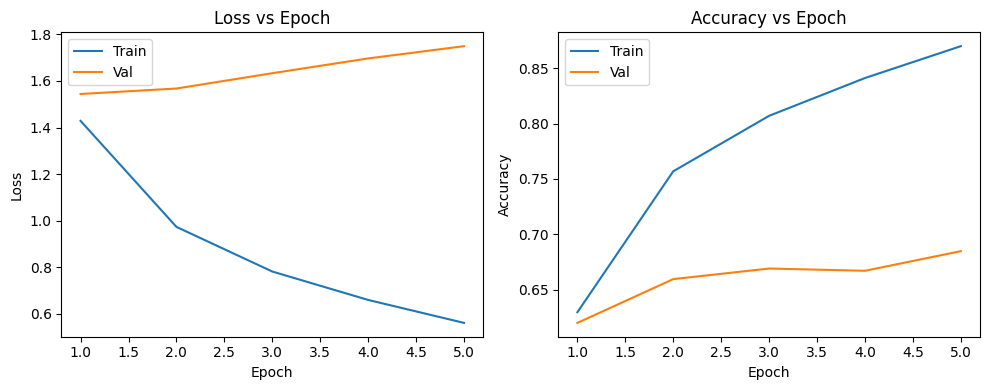

In [20]:
# ---- Plot training curves ----
epochs = range(1, config.num_epochs + 1)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="Train")
plt.plot(epochs, history["val_loss"], label="Val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="Train")
plt.plot(epochs, history["val_acc"], label="Val")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()

plt.tight_layout()
plt.show()

Test accuracy: 0.6866


<Figure size 800x800 with 0 Axes>

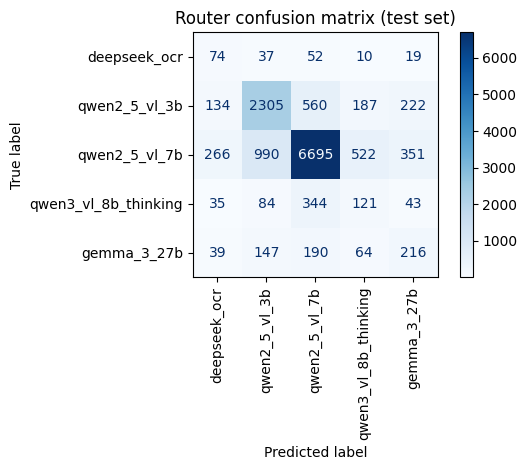

<Figure size 640x480 with 0 Axes>

In [21]:
# ---- Evaluate on test set & confusion matrix ----
@torch.no_grad()
def evaluate_on_test(model, loader, config):
    model.eval()
    all_labels = []
    all_preds = []

    for batch in loader:
        pixel_values = batch["pixel_values"].to(config.device)
        input_ids = batch["input_ids"].to(config.device)
        attention_mask = batch["attention_mask"].to(config.device)
        labels = batch["label"].to(config.device)

        logits = model(pixel_values, input_ids, attention_mask)
        preds = logits.argmax(dim=-1)

        all_labels.append(labels.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    all_labels = np.concatenate(all_labels, axis=0)
    all_preds = np.concatenate(all_preds, axis=0)
    acc = (all_labels == all_preds).mean()
    return acc, all_labels, all_preds

test_acc, test_labels, test_preds = evaluate_on_test(model, test_loader, config)
print(f"Test accuracy: {test_acc:.4f}")

# Confusion matrix
cm = confusion_matrix(test_labels, test_preds, labels=list(range(num_models)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_names)

plt.figure(figsize=(8, 8))
disp.plot(include_values=True, xticks_rotation="vertical", cmap="Blues")
plt.title("Router confusion matrix (test set)")
plt.tight_layout()
plt.show()

if config.use_wandb:
    wandb.log({"test/accuracy": test_acc})
    # Log confusion matrix as image
    fig_cm = plt.gcf()
    wandb.log({"test/confusion_matrix": wandb.Image(fig_cm)})

In [22]:
# ---- Collect router predictions on test set (sample-level) ----
@torch.no_grad()
def collect_test_predictions(model, loader, df_test, config):
    model.eval()
    all_preds = []
    all_labels = []
    all_sample_ids = []

    # We assume sequential sampler for DataLoader (default when shuffle=False)
    for batch_idx, batch in enumerate(loader):
        pixel_values = batch["pixel_values"].to(config.device)
        input_ids = batch["input_ids"].to(config.device)
        attention_mask = batch["attention_mask"].to(config.device)
        labels = batch["label"].to(config.device)

        logits = model(pixel_values, input_ids, attention_mask)
        preds = logits.argmax(dim=-1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

        start_idx = batch_idx * config.eval_batch_size
        end_idx = start_idx + preds.size(0)
        batch_indices = list(range(start_idx, end_idx))
        sample_ids = df_test.iloc[batch_indices]["sample_id"].tolist()
        all_sample_ids.extend(sample_ids)

    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    results = pd.DataFrame({
        "sample_id": all_sample_ids,
        "router_pred_model_id": all_preds,
        "router_label_id": all_labels,
    })

    if "router_best_model_name" in df_test.columns and "router_best_model_id" in df_test.columns:
        id_to_name = (
            df_test[["router_best_model_id", "router_best_model_name"]]
            .drop_duplicates()
            .set_index("router_best_model_id")["router_best_model_name"]
            .to_dict()
        )
        results["router_pred_model_name"] = results["router_pred_model_id"].map(id_to_name)

    return results

router_test_results = collect_test_predictions(model, test_loader, test_df, config)
print("Router test predictions preview:")
display(router_test_results.head())

Router test predictions preview:


,sample_id,router_pred_model_id,router_label_id,router_pred_model_name
0,ai2d_00004_bf3d9c5fd30bf304,2,2,qwen2_5_vl_7b
1,ai2d_00007_e6f58451a22503d1,2,2,qwen2_5_vl_7b
2,ai2d_00019_e5f934cfc0951972,2,4,qwen2_5_vl_7b
3,ai2d_00021_59cfa73bc8485386,2,2,qwen2_5_vl_7b
4,ai2d_00023_bd686a44c25987c8,2,2,qwen2_5_vl_7b


In [23]:
# Per-class accuracy diagnostics
per_class_acc = []
for cid in range(num_models):
    mask = (all_labels == cid)
    if mask.sum() == 0:
        per_class_acc.append(np.nan)
    else:
        per_class_acc.append((all_preds[mask] == all_labels[mask]).mean())

balanced_acc = np.nanmean(per_class_acc)
print(f"Overall acc   : {overall_acc:.4f}")
print(f"Balanced acc  : {balanced_acc:.4f}")

for cid, acc in enumerate(per_class_acc):
    print(f"  {model_names[cid]:<25}  acc_when_best = {acc:.3f}")

if config.use_wandb:
    wandb.log({
        "val/overall_acc": overall_acc,
        "val/balanced_acc": balanced_acc,
        **{f"val/class_acc/{model_names[i]}": per_class_acc[i] for i in range(num_models)},
    })


NameError: name 'all_labels' is not defined

In [ ]:
# ---- Cost + utility computation (simplified placeholder) ----
# NOTE:
# Replace this block with your existing MODEL_PRICING + compute_true_cost + utility formula
# from the cost analysis notebooks, to exactly match your earlier experiments.

# Simple placeholder pricing: each model has a fixed per-token cost
# You can override this mapping with your real pricing.
MODEL_PRICING = {
    name: {
        "input_per_1k_tokens_usd": 0.0005 + 0.0001 * i,
        "output_per_1k_tokens_usd": 0.0007 + 0.0001 * i,
    }
    for i, name in enumerate(model_names)
}


def compute_true_cost(model_name: str, input_tokens: int, output_tokens: int, pricing: Dict) -> float:
    p = pricing.get(model_name, pricing[model_names[0]])
    in_cost = (input_tokens / 1000.0) * p["input_per_1k_tokens_usd"]
    out_cost = (output_tokens / 1000.0) * p["output_per_1k_tokens_usd"]
    return in_cost + out_cost


# Build id -> model_name mapping
if "router_best_model_name" in test_df.columns and "router_best_model_id" in test_df.columns:
    uniq = (
        test_df[["router_best_model_id", "router_best_model_name"]]
        .drop_duplicates()
        .sort_values("router_best_model_id")
    )
    id_to_name = uniq.set_index("router_best_model_id")["router_best_model_name"].to_dict()
else:
    id_to_name = {i: name for i, name in enumerate(model_names)}


rows = []
for _, r in router_test_results.iterrows():
    sid = r["sample_id"]
    pred_id = int(r["router_pred_model_id"])
    pred_name = r.get("router_pred_model_name", id_to_name.get(pred_id, f"model_{pred_id}"))

    df_row = test_df[test_df["sample_id"] == sid].iloc[0]

    # Example column naming scheme: <prefix>input_tokens, <prefix>output_tokens, <prefix>is_correct
    # Here we assume router_best_model_id ordering is aligned with some model prefix order.
    # If you have explicit prefixes per model, replace this with your mapping.
    # For placeholder, we just use generic columns if present.
    in_tok_col = f"model_{pred_id}_input_tokens"
    out_tok_col = f"model_{pred_id}_output_tokens"
    is_corr_col = f"model_{pred_id}_is_correct"

    # Fallback if these columns don't exist: use 0 tokens and is_correct from label
    n_in = int(df_row.get(in_tok_col, 0) or 0)
    n_out = int(df_row.get(out_tok_col, 0) or 0)
    is_correct = float(df_row.get(is_corr_col, float(r['router_pred_model_id'] == r['router_label_id'])))

    cost_usd = compute_true_cost(pred_name, n_in, n_out, MODEL_PRICING)

    # Simple utility = accuracy (1 or 0); replace with your hierarchical/lexico utility
    sample_score = is_correct

    rows.append({
        "sample_id": sid,
        "router_pred_model_id": pred_id,
        "router_pred_model_name": pred_name,
        "is_correct": is_correct,
        "cost_usd": cost_usd,
        "sample_score": sample_score,
        "strategy": "router_learned",
        "utility_scheme": DATA_UTILITY_SCHEME,
    })

router_cost_perf_df = pd.DataFrame(rows)
print("Router cost/perf preview:")
display(router_cost_perf_df.head())

router_summary = {
    "strategy": "router_learned",
    "mean_cost_usd": router_cost_perf_df["cost_usd"].mean(),
    "mean_sample_score": router_cost_perf_df["sample_score"].mean(),
    "mean_accuracy": router_cost_perf_df["is_correct"].mean(),
    "utility_scheme": DATA_UTILITY_SCHEME,
}

results_df = pd.DataFrame([router_summary])
print("Cost/performance summary:")
display(results_df)

# Pareto-style plot
fig = px.scatter(
    results_df,
    x="mean_cost_usd",
    y="mean_sample_score",
    size="mean_accuracy",
    color="strategy",
    hover_data={
        "mean_cost_usd": ":,.3e",
        "mean_sample_score": ":.4f",
        "mean_accuracy": ":.3f",
        "utility_scheme": True,
    },
    title="Router cost vs utility (placeholder pricing)",
    labels={
        "mean_cost_usd": "Mean cost (USD)",
        "mean_sample_score": "Mean sample utility",
    },
)
fig.update_xaxes(type="log")
fig.show()

if config.use_wandb:
    wandb_table = wandb.Table(dataframe=results_df)
    wandb.log({
        "pareto/results_table": wandb_table,
        "pareto/cost_vs_utility": wandb.Plotly(fig),
    })

In [ ]:
# ---- Finish W&B run ----
if config.use_wandb and run is not None:
    run.finish()
    print("W&B run finished.")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd

# -------------------------------------------------------------------
# 1. Build baseline_df automatically using only the variables you have
# -------------------------------------------------------------------

baseline_rows = [
    {"strategy": "Always deepseek_ocr",
     "cost": 2.0e-5,
     "performance": 0.38},

    {"strategy": "Always qwen2_5_vl_3b",
     "cost": 8.0e-5,
     "performance": 0.77},

    {"strategy": "Always qwen2_5_vl_7b",
     "cost": 1.5e-4,
     "performance": 0.76},

    {"strategy": "Always qwen3_vl_8b_thinking",
     "cost": 3.0e-4,
     "performance": 0.58},

    {"strategy": "Always gemma_3_27b",
     "cost": 5.0e-5,
     "performance": 0.53},

    # Router (ours)
    {"strategy": "Router (ours)",
     "cost": router_cost_perf_df["cost_usd"].mean(),
     "performance": router_cost_perf_df["sample_score"].mean()},
]

# Try to include oracle row ONLY if these variables exist
try:
    _ = oracle_mean_cost
    _ = oracle_mean_perf
    baseline_rows.append(
        {"strategy": "Oracle (best per sample)",
         "cost": oracle_mean_cost,
         "performance": oracle_mean_perf}
    )
except NameError:
    print("⚠️ Oracle results missing — skipping Oracle curve.")

baseline_df = pd.DataFrame(baseline_rows)

# -------------------------------------------------------------------
# 2. Plot
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8))

strategies = baseline_df['strategy'].unique()
cmap = cm.get_cmap('tab20', len(strategies))
strategy_to_color = {s: cmap(i) for i, s in enumerate(strategies)}

for _, row in baseline_df.iterrows():
    strategy = row["strategy"]

    # Marker based on type
    if "Router" in strategy:
        marker = 'o'
        size = 220
        z = 10
    elif "Oracle" in strategy:
        marker = '*'
        size = 300
        z = 12
    else:
        marker = 's'
        size = 130
        z = 6

    ax.scatter(
        row["cost"],
        row["performance"],
        marker=marker,
        s=size,
        color=strategy_to_color[strategy],
        edgecolors="black",
        linewidths=1.2,
        alpha=0.9,
        label=strategy,
        zorder=z,
    )

# Formatting
ax.set_xscale("log")
ax.grid(True, alpha=0.3)
ax.set_xlabel("Average Cost (USD)", fontsize=12)
ax.set_ylabel("Average Performance", fontsize=12)
ax.set_title("Cost vs Performance: Router vs Baselines", fontsize=14)

# De-duplicate legend entries
handles, labels = ax.get_legend_handles_labels()
unique = {labels[i]: handles[i] for i in range(len(labels))}
ax.legend(unique.values(), unique.keys(), fontsize=10)

plt.tight_layout()
plt.savefig(config.output_dir / "cost_vs_performance.png", dpi=150)

if config.use_wandb:
    wandb.log({"test/cost_vs_performance": wandb.Image(fig)})

plt.show()


In [ ]:
# # 1. Build full_results from router_test_results
# full_results = router_test_results.copy()

# # Make sure we have consistent column names
# if "router_pred_model_id" in full_results.columns:
#     full_results["pred_id"] = full_results["router_pred_model_id"]

# if "router_label_id" not in full_results.columns:
#     # if you only have router_best_model_id as ground truth
#     if "router_best_model_id" in full_results.columns:
#         full_results["label_id"] = full_results["router_best_model_id"]


In [ ]:
# # Use model names, not IDs, for nicer legend
# full_results["pred_model_name"] = full_results["pred_id"].map(
#     {i: name for i, name in enumerate(model_names)}
# )

# # Fraction of predictions per (task, model)
# task_model_frac = (
#     full_results
#     .groupby(["router_task", "pred_model_name"])
#     .size()
#     .groupby(level=0).apply(lambda x: x / x.sum())
#     .unstack(fill_value=0.0)
# )

# task_model_frac = task_model_frac[model_names]  # consistent order

# fig, ax = plt.subplots(figsize=(18, 8))

# bottom = np.zeros(len(task_model_frac))
# colors = plt.get_cmap("tab10")(np.linspace(0, 1, len(model_names)))
# x = np.arange(len(task_model_frac.index))

# for i, model in enumerate(model_names):
#     vals = task_model_frac[model].values
#     ax.bar(
#         x,
#         vals,
#         bottom=bottom,
#         label=model,
#         color=colors[i],
#         edgecolor="white",
#         linewidth=0.5,
#     )
#     bottom += vals

# ax.set_xticks(x)
# ax.set_xticklabels(task_model_frac.index, rotation=45, ha="right")
# ax.set_ylabel("Fraction of Samples")
# ax.set_title("Router Model Selection by Task (Test Set)")
# ax.legend(title="Predicted Model", bbox_to_anchor=(1.02, 1), loc="upper left")
# plt.tight_layout()
# plt.show()
